In [1]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
import optuna
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

recall=  TP / (TP + FN)
precision = TP / (TP + FP)

In [2]:
with open('../../data/enhanced_trades_df_v2.pkl', 'rb') as f:
    trades = pickle.load(f)

In [3]:
# trades["random_feature"] = np.random.randn(len(trades))

In [4]:
trades=trades.sort_values(by="entry_date")

In [5]:
trades

,Symbol,entry_date,entry_price,exit_date,exit_price,return,Close,stock_ret_1d,rsi,adx,...,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,Industry,hmm_cluster,Industry_woe,cluster_win_loss_ratio
2396,NMDC,2016-03-09,13.149165,2016-04-28,13.738341,4.480711,13.149165,-0.015344,75.574806,33.866604,...,0.000438,-0.943376,13.231202,1.863594,0.137517,1,Metals & Mining,0.0,0.171921,0.815166
1419,HINDALCO,2016-03-21,80.699150,2016-03-30,82.575851,2.325553,80.699150,0.009390,66.985118,30.847063,...,0.000358,-0.152065,33.855358,0.968967,0.063425,1,Metals & Mining,3.0,0.171921,0.512195
3240,TATASTEEL,2016-03-21,22.325666,2016-05-05,24.403414,9.306541,22.325666,0.004467,73.931740,30.156950,...,0.000155,-0.579234,35.126138,1.071643,0.016532,1,Metals & Mining,3.0,0.171921,0.512195
598,BHARTIARTL,2016-03-22,299.554504,2016-04-01,286.365204,-4.402972,299.554504,-0.007776,68.502922,30.521119,...,0.000175,0.457509,83.115273,1.333358,0.015242,0,Telecommunication,3.0,-0.170878,0.512195
2815,RELIANCE,2016-03-22,229.608643,2016-03-28,223.593719,-2.619641,229.608643,0.010171,67.560319,30.172319,...,0.000280,0.116702,80.890779,1.781608,0.113989,0,Oil Gas & Consumable Fuels,3.0,0.041870,0.512195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1692,INDIGO,2025-08-27,6050.000000,2025-08-28,5727.000000,-5.338843,6050.000000,0.000000,57.705115,30.314948,...,0.000106,3.992301,603.398978,0.451727,0.000000,0,Services,1.0,-0.240706,0.744048
3580,VMM,2025-08-27,153.139999,2025-09-02,146.330002,-4.446910,153.139999,0.000000,68.060884,31.580026,...,0.000392,1.153450,218.252956,2.544196,0.000000,0,Consumer Services,1.0,0.189966,0.744048
2209,MFSL,2025-08-29,1602.199951,2025-09-04,1566.000000,-2.259390,1602.199951,-0.004041,53.859737,30.395963,...,0.000116,-0.450856,49.298656,0.452576,-0.124731,0,Financial Services,1.0,-0.029508,0.744048
3360,TITAN,2025-08-29,3628.800049,2025-09-15,3534.100098,-2.609677,3628.800049,-0.002447,64.093506,31.060234,...,0.000062,-0.379968,97.851273,1.078735,0.072640,0,Consumer Durables,1.0,0.183092,0.744048


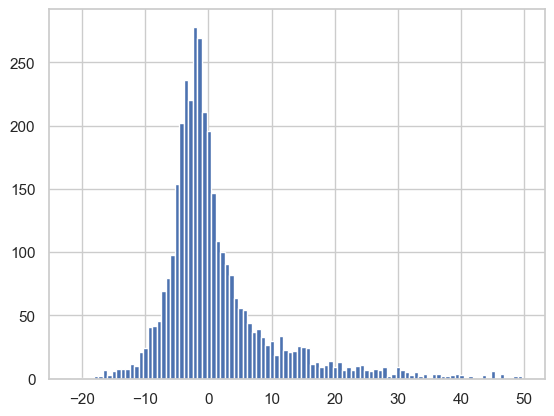

In [6]:
trades[(trades["return"]<50) & (trades["return"]>-40)]["return"].hist(bins=100);

In [27]:
trades["result"] = np.where(trades["return"] <= 0, 0, 1)

In [28]:
print(trades["result"].value_counts())

result
0    2166
1    1503
Name: count, dtype: int64


In [29]:
trades.columns

Index(['Symbol', 'entry_date', 'entry_price', 'exit_date', 'exit_price',
       'return', 'Close', 'stock_ret_1d', 'rsi', 'adx', 'Index_Close',
       'index_ret_1d', 'index_ret_5d', 'index_ret_20d', 'index_vol',
       'index_vol_5d', 'index_vol_20d', 'plus_di', 'minus_di', 'rsi_5_chg',
       'adx_5_chg', 'roc_5', 'atr_5_chg', 'vol_chg_5d', 'volatility_5d',
       '5_days_high', 'rsi_10_chg', 'adx_10_chg', 'roc_10', 'atr_10_chg',
       'vol_chg_10d', 'volatility_10d', '10_days_high', 'rsi_20_chg',
       'adx_20_chg', 'roc_20', 'atr_20_chg', 'vol_chg_20d', 'volatility_20d',
       '20_days_high', 'beta', 'corr', 'stock_vol', 'excess_vol',
       'volatility_of_volatility', 'dsv', 'vol_z', 'vol_vol_ratio', 'obv_z',
       'vwap_dev', 'result', 'Industry', 'hmm_cluster', 'Industry_woe',
       'cluster_win_loss_ratio'],
      dtype='object')

In [30]:
to_drop = ["Symbol", "entry_price", "exit_date","exit_price","Close","return" ,"Industry", "Index_Close", 'entry_date']

In [31]:
df= trades.drop(columns=to_drop)

In [32]:
df

,stock_ret_1d,rsi,adx,index_ret_1d,index_ret_5d,index_ret_20d,index_vol,index_vol_5d,index_vol_20d,plus_di,...,volatility_of_volatility,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,hmm_cluster,Industry_woe,cluster_win_loss_ratio
2396,-0.015344,75.574806,33.866604,0.006212,0.042853,0.032008,0.015809,0.008721,0.015809,42.862165,...,0.004685,0.000438,-0.943376,13.231202,1.863594,0.137517,1,0.0,0.171921,0.815166
1419,0.009390,66.985118,30.847063,0.013137,0.021953,0.068439,0.011955,0.009521,0.011955,31.471365,...,0.004331,0.000358,-0.152065,33.855358,0.968967,0.063425,1,3.0,0.171921,0.512195
3240,0.004467,73.931740,30.156950,0.013137,0.021953,0.068439,0.011955,0.009521,0.011955,31.415420,...,0.008066,0.000155,-0.579234,35.126138,1.071643,0.016532,1,3.0,0.171921,0.512195
598,-0.007776,68.502922,30.521119,0.001382,0.034086,0.066397,0.011964,0.005619,0.011964,24.215227,...,0.002222,0.000175,0.457509,83.115273,1.333358,0.015242,0,3.0,-0.170878,0.512195
2815,0.010171,67.560319,30.172319,0.001382,0.034086,0.066397,0.011964,0.005619,0.011964,29.992586,...,0.002951,0.000280,0.116702,80.890779,1.781608,0.113989,0,3.0,0.041870,0.512195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1692,0.000000,57.705115,30.314948,-0.008544,-0.021942,-0.012900,0.006253,0.006526,0.006253,24.629198,...,0.000636,0.000106,3.992301,603.398978,0.451727,0.000000,0,1.0,-0.240706,0.744048
3580,0.000000,68.060884,31.580026,-0.008544,-0.021942,-0.012900,0.006253,0.006526,0.006253,32.114406,...,0.001744,0.000392,1.153450,218.252956,2.544196,0.000000,0,1.0,0.189966,0.744048
2209,-0.004041,53.859737,30.395963,-0.003022,-0.026188,-0.017228,0.006257,0.005823,0.006257,31.244059,...,0.001349,0.000116,-0.450856,49.298656,0.452576,-0.124731,0,1.0,-0.029508,0.744048
3360,-0.002447,64.093506,31.060234,-0.003022,-0.026188,-0.017228,0.006257,0.005823,0.006257,32.793803,...,0.001865,0.000062,-0.379968,97.851273,1.078735,0.072640,0,1.0,0.183092,0.744048


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3669 entries, 2396 to 3601
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   stock_ret_1d              3669 non-null   float32
 1   rsi                       3669 non-null   float64
 2   adx                       3669 non-null   float64
 3   index_ret_1d              3669 non-null   float64
 4   index_ret_5d              3669 non-null   float64
 5   index_ret_20d             3669 non-null   float64
 6   index_vol                 3669 non-null   float64
 7   index_vol_5d              3669 non-null   float64
 8   index_vol_20d             3669 non-null   float64
 9   plus_di                   3669 non-null   float64
 10  minus_di                  3669 non-null   float64
 11  rsi_5_chg                 3669 non-null   float64
 12  adx_5_chg                 3669 non-null   float64
 13  roc_5                     3669 non-null   float64
 14  atr_5_chg 

In [34]:
df.columns.sort_values()

Index(['10_days_high', '20_days_high', '5_days_high', 'Industry_woe', 'adx',
       'adx_10_chg', 'adx_20_chg', 'adx_5_chg', 'atr_10_chg', 'atr_20_chg',
       'atr_5_chg', 'beta', 'cluster_win_loss_ratio', 'corr', 'dsv',
       'excess_vol', 'hmm_cluster', 'index_ret_1d', 'index_ret_20d',
       'index_ret_5d', 'index_vol', 'index_vol_20d', 'index_vol_5d',
       'minus_di', 'obv_z', 'plus_di', 'result', 'roc_10', 'roc_20', 'roc_5',
       'rsi', 'rsi_10_chg', 'rsi_20_chg', 'rsi_5_chg', 'stock_ret_1d',
       'stock_vol', 'vol_chg_10d', 'vol_chg_20d', 'vol_chg_5d',
       'vol_vol_ratio', 'vol_z', 'volatility_10d', 'volatility_20d',
       'volatility_5d', 'volatility_of_volatility', 'vwap_dev'],
      dtype='object')

In [35]:
cols = ['dsv', 'excess_vol', 'gk_vol', 
    'index_ret_5d', 'index_ret_20d', 'index_vol_5d', 'index_vol_20d','hmm_cluster', 
    'result' ]

In [36]:
cols = [
       'atr_10_chg', 'atr_20_chg',
    'index_ret_5d', 'index_ret_20d', 'index_vol_5d', 'index_vol_20d', 'vol_chg_10d', 'vol_chg_20d', 'vol_chg_5d', 'volatility_10d', 'volatility_20d',
    'result' ]

In [37]:
df = df[cols]

In [38]:
# X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["result"]), df["result"], test_size=0.2, random_state=42, stratify=df["result"])

# get first 80% of rows as training set and last 20% as test set
train_size = int(0.8 * len(df))
X_train = df.drop(columns=["result"]).iloc[:train_size]
X_test = df.drop(columns=["result"]).iloc[train_size:]
y_train = df["result"].iloc[:train_size]
y_test = df["result"].iloc[train_size:]

In [39]:
X_train

,atr_10_chg,atr_20_chg,index_ret_5d,index_ret_20d,index_vol_5d,index_vol_20d,vol_chg_10d,vol_chg_20d,vol_chg_5d,volatility_10d,volatility_20d
2396,0.165470,0.478777,0.042853,0.032008,0.008721,0.015809,-0.597268,0.814865,0.059312,0.024825,0.039271
1419,-0.022858,-0.027869,0.021953,0.068439,0.009521,0.011955,-0.221978,1.037568,0.855372,0.028500,0.029232
3240,-0.159776,-0.217763,0.021953,0.068439,0.009521,0.011955,-0.383685,-0.165259,0.271385,0.010455,0.020720
598,-0.010878,-0.078105,0.034086,0.066397,0.005619,0.011964,0.848752,0.280783,0.916172,0.010815,0.013236
2815,-0.131682,-0.240827,0.034086,0.066397,0.005619,0.011964,0.159604,0.200661,0.462028,0.012101,0.012103
...,...,...,...,...,...,...,...,...,...,...,...
3666,-0.010596,0.170781,-0.002774,-0.020814,0.003874,0.004556,-0.203771,0.251261,0.159383,0.013198,0.011990
368,-0.112041,-0.027918,-0.002774,-0.020814,0.003874,0.004556,-0.589547,-0.193926,-0.485737,0.004783,0.012191
1587,0.165649,0.103974,-0.004966,-0.019566,0.003560,0.004565,1.326960,2.562465,2.002261,0.032502,0.030363
644,0.325860,0.426420,-0.006855,-0.013968,0.003904,0.004096,5.179753,1.390913,0.587746,0.039033,0.032283


In [40]:
# one_hot_cols = ["hmm_cluster"]
# ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# train_ohe = ohe.fit_transform(X_train[one_hot_cols])
# test_ohe = ohe.transform(X_test[one_hot_cols])

# train_ohe_df = pd.DataFrame(train_ohe, columns=ohe.get_feature_names_out(one_hot_cols), index=X_train.index)
# test_ohe_df = pd.DataFrame(test_ohe, columns=ohe.get_feature_names_out(one_hot_cols), index=X_test.index)

# X_train_ohe = pd.concat([X_train.drop(columns=one_hot_cols), train_ohe_df], axis=1)
# X_test_ohe = pd.concat([X_test.drop(columns=one_hot_cols), test_ohe_df], axis=1)

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [41]:
X_train_scaled

,atr_10_chg,atr_20_chg,index_ret_5d,index_ret_20d,index_vol_5d,index_vol_20d,vol_chg_10d,vol_chg_20d,vol_chg_5d,volatility_10d,volatility_20d
2396,0.174450,1.295762,1.877263,-0.046592,0.283342,1.781101,-0.386279,-0.104753,-0.018683,0.210975,1.749384
1419,-0.706792,-0.674096,0.707917,1.010940,0.457729,0.888440,-0.320185,-0.081846,-0.018522,0.498053,0.768509
3240,-1.347470,-1.412409,0.707917,1.010940,0.457729,0.888440,-0.348664,-0.205568,-0.018640,-0.911698,-0.063207
598,-0.650734,-0.869413,1.386718,0.951642,-0.393152,0.890383,-0.131614,-0.159688,-0.018509,-0.883547,-0.794488
2815,-1.216010,-1.502081,1.386718,0.951642,-0.393152,0.890383,-0.252983,-0.167929,-0.018601,-0.783118,-0.905197
...,...,...,...,...,...,...,...,...,...,...,...
3666,-0.649413,0.098262,-0.675532,-1.579888,-0.773764,-0.825596,-0.316979,-0.162725,-0.018663,-0.697381,-0.916159
368,-1.124106,-0.674286,-0.675532,-1.579888,-0.773764,-0.825596,-0.384920,-0.208516,-0.018793,-1.354810,-0.896547
1587,0.175288,-0.161485,-0.798170,-1.543662,-0.842265,-0.823482,-0.047395,0.075003,-0.018289,0.810739,0.878962
644,0.924965,1.092197,-0.903889,-1.381176,-0.767188,-0.932092,0.631139,-0.045501,-0.018576,1.320947,1.066556


In [42]:
# pca = PCA(n_components=30, random_state=42)
# X_train_pca=pca.fit_transform(X_train_scaled)
# X_test_pca=pca.transform(X_test_scaled)
# X_train_pca = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])], index=X_train.index)
# X_test_pca = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])], index=X_test.index)
# # df_pca['result'] = y_train

In [43]:
# X_train_pca

In [44]:
# calculate class weights
class_weights = y_train.value_counts(normalize=True)
class_weights = {cls: 1/weight for cls, weight in class_weights.items()}
class_weights

{0: 1.680022896393818, 1: 2.4705387205387206}

In [127]:
# class_weights = {0: 1, 1: 1.2}

In [128]:
X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape

((2935, 12), (734, 12), (2935,), (734,))

In [129]:
def y_train_shuffle(random_state=42):
    return y_train.sample(frac=1, random_state=random_state).reset_index(drop=True).copy()

In [130]:
for c in [0.001, 0.01, 0.1, 1, 10, 100]:
    print(f"Class weight: {c}")
    lg = LogisticRegression(class_weight=class_weights, C=c, max_iter=1000, random_state=42, n_jobs=-1)
    lg.fit(X_train_scaled, y_train)
    predictions = lg.predict(X_test_scaled)
    print(classification_report(y_test, predictions))

Class weight: 0.001
              precision    recall  f1-score   support

           0       0.43      0.82      0.56       315
           1       0.57      0.18      0.28       419

    accuracy                           0.46       734
   macro avg       0.50      0.50      0.42       734
weighted avg       0.51      0.46      0.40       734

Class weight: 0.01
              precision    recall  f1-score   support

           0       0.42      0.76      0.54       315
           1       0.53      0.21      0.30       419

    accuracy                           0.44       734
   macro avg       0.48      0.48      0.42       734
weighted avg       0.48      0.44      0.40       734

Class weight: 0.1
              precision    recall  f1-score   support

           0       0.42      0.74      0.54       315
           1       0.54      0.23      0.32       419

    accuracy                           0.45       734
   macro avg       0.48      0.49      0.43       734
weighted avg     

In [33]:
predictions = lg.predict(X_test_scaled)

In [46]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.63      0.54      0.58       433
           1       0.45      0.54      0.49       301

    accuracy                           0.54       734
   macro avg       0.54      0.54      0.53       734
weighted avg       0.55      0.54      0.54       734



<Axes: title={'center': 'Feature Importance'}>

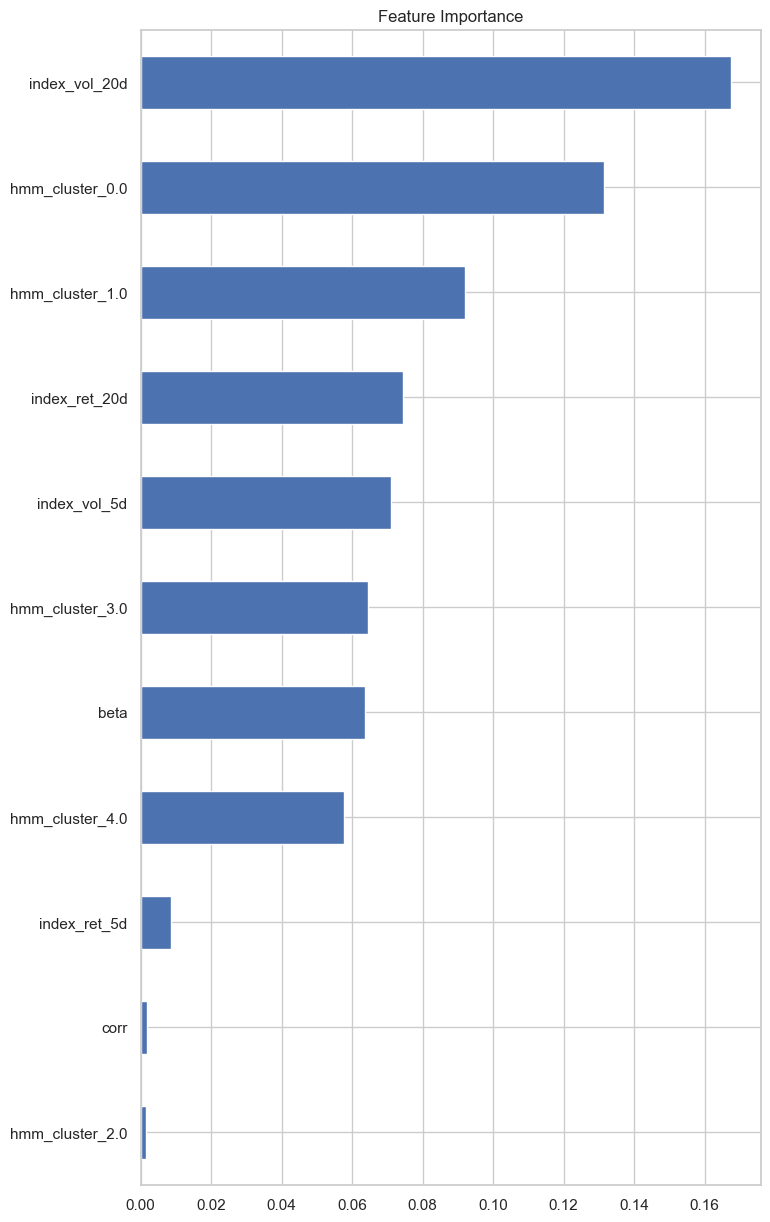

In [26]:
# plot feature importance
plt.figure(figsize=(8,15))
importance = pd.Series(lg.coef_[0], index=X_train_scaled.columns)
# make values absolute
importance = importance.abs()
importance = importance.sort_values()
importance.plot(kind='barh', title='Feature Importance')

In [104]:
rf = RandomForestClassifier(class_weight=class_weights, n_estimators=100, random_state=42, n_jobs=-1, max_depth=5)
rf.fit(X_train_scaled, y_train)
predictions_rf = rf.predict(X_test_scaled)
print("Random Forest Classifier")
print(classification_report(y_test, predictions_rf))

Random Forest Classifier
              precision    recall  f1-score   support

           0       0.71      0.59      0.65       511
           1       0.33      0.45      0.38       223

    accuracy                           0.55       734
   macro avg       0.52      0.52      0.51       734
weighted avg       0.60      0.55      0.57       734



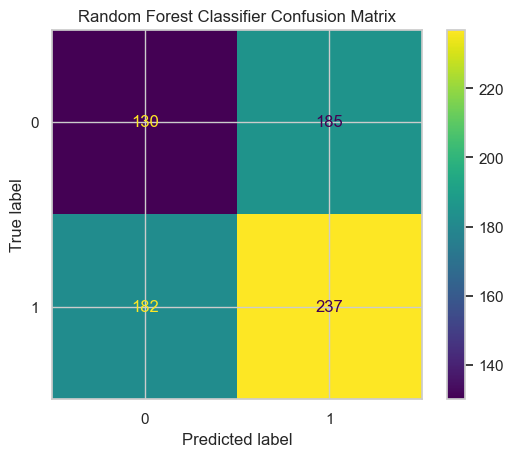

In [29]:
# confusion matrix
cm = confusion_matrix(y_test, predictions_rf, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot()
plt.title("Random Forest Classifier Confusion Matrix")
plt.show()

In [30]:
# Get prediction probabilities
y_proba = rf.predict_proba(X_test_scaled)[:, 1]  # probability of profit (class 1)

# Try different thresholds
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

for threshold in thresholds:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, y_pred_thresh))
    
    # Calculate profit recall specifically
    profit_recall = recall_score(y_test, y_pred_thresh, pos_label=1)
    print(f"Loss Recall: {profit_recall:.3f}")


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       315
           1       0.57      1.00      0.73       419

    accuracy                           0.57       734
   macro avg       0.29      0.50      0.36       734
weighted avg       0.33      0.57      0.41       734

Loss Recall: 1.000

Threshold: 0.35
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       315
           1       0.57      1.00      0.73       419

    accuracy                           0.57       734
   macro avg       0.29      0.50      0.36       734
weighted avg       0.33      0.57      0.41       734

Loss Recall: 1.000

Threshold: 0.4
              precision    recall  f1-score   support

           0       1.00      0.00      0.01       315
           1       0.57      1.00      0.73       419

    accuracy                           0.57       734
   macro avg       0.79      0.50      0.

/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/lib/python3.12/sit

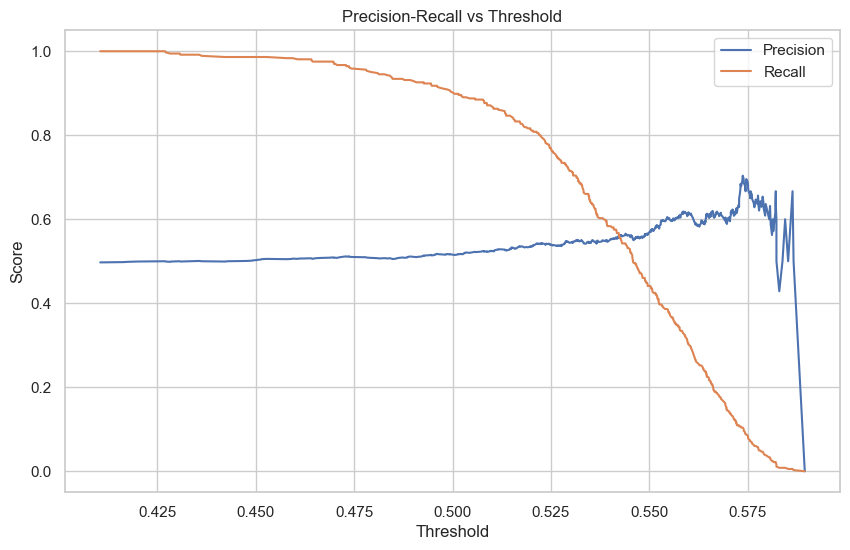

In [83]:
from sklearn.metrics import precision_recall_curve

# Plot precision-recall curve to find optimal threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall') 
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

n_estimators: 279
    learning_rate: 0.07102467817012613
    max_depth: 30
    num_leaves: 168

In [106]:
lgb = LGBMClassifier(class_weight=class_weights, n_estimators=279, n_jobs=-1, max_depth=30, num_leaves=168, learning_rate=0.0710)
# shuffle y_train
lgb.fit(X_train_scaled, y_train)
predictions_lgb = lgb.predict(X_test_scaled)
print("LightGBM Classifier")
print(classification_report(y_test, predictions_lgb))

[LightGBM] [Info] Number of positive: 912, number of negative: 2023
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000605 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1797
[LightGBM] [Info] Number of data points in the train set: 2935, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

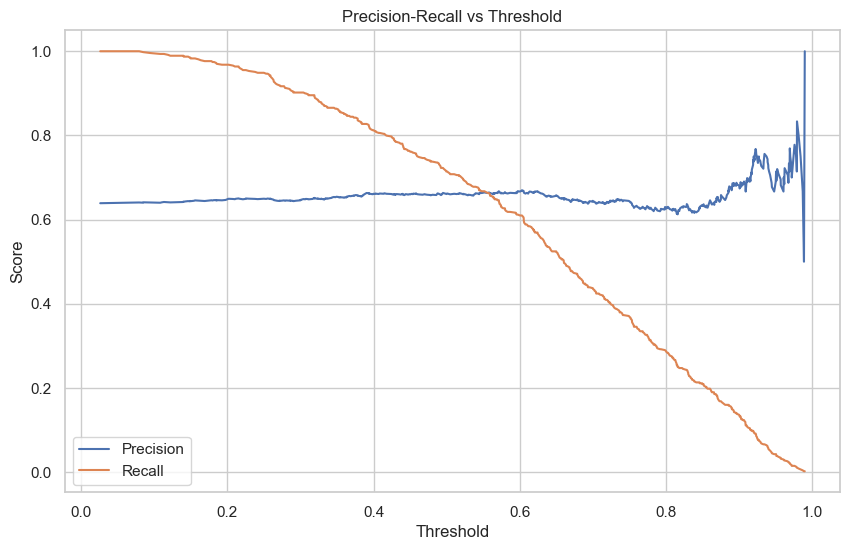

In [34]:
y_proba = lgb.predict_proba(X_test_scaled)[:, 1]  # probability of profit (class 1)
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall') 
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

In [ ]:
# set up optuna for LightGBM
def objective_lgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 32),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'class_weight': class_weights,
        'random_state': 42,
        'n_jobs': -1,

    }
    
    model = LGBMClassifier(**param)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    f1 = f1_score(y_test, preds)
    return f1
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=30)
print("Best trial:")
trial = study_lgb.best_trial
print(f"  F1 Score: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")    

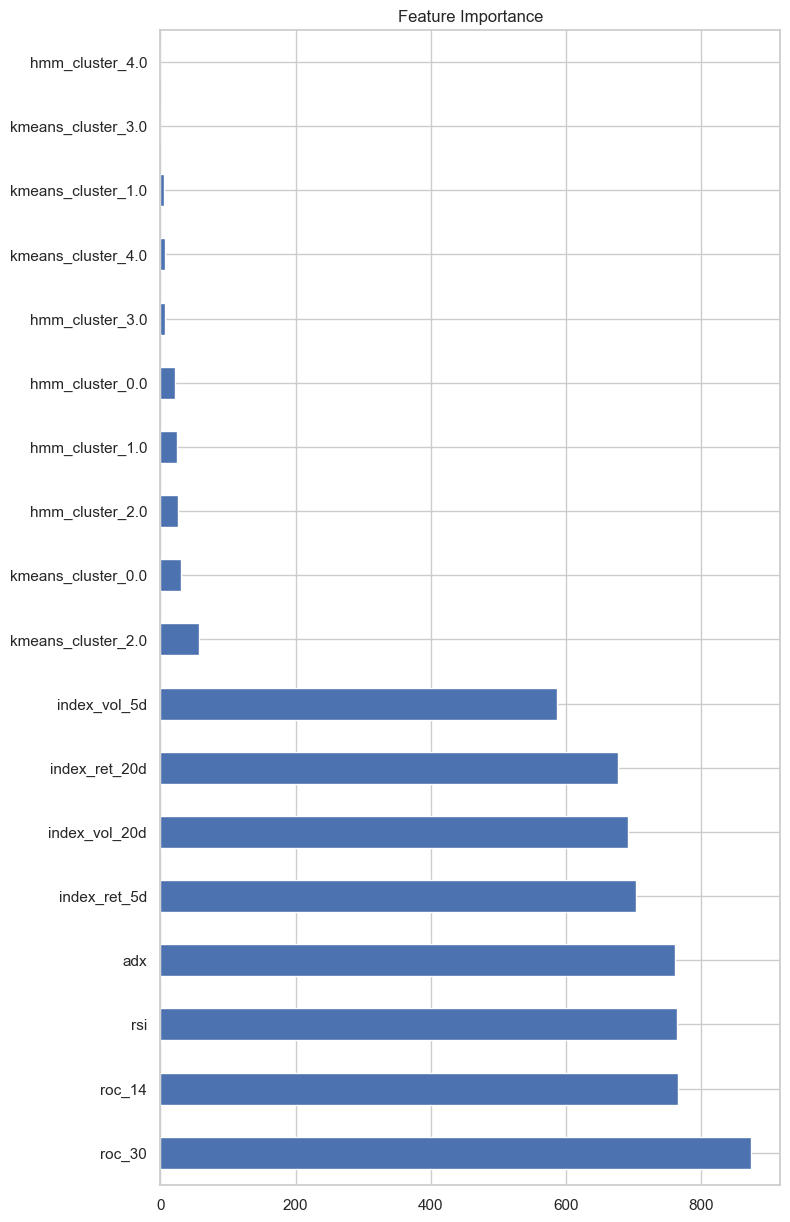

In [35]:
# plot feature importance
plt.figure(figsize=(8,15))
importance = pd.Series(lgb.feature_importances_, index=X_train_scaled.columns)
importance = importance.sort_values(ascending=False)
importance.plot(kind='barh', title='Feature Importance')
plt.show()

In [36]:
class_weights[0]/class_weights[1]

0.37213651238896683

F1 Score: 0.8119022316684378
  Params: 
 n_estimators: 50
    max_depth: 3
    learning_rate: 0.24504786215696017

In [47]:
xgb = XGBClassifier(scale_pos_weight=class_weights[1]/class_weights[0], n_estimators=50, learning_rate=0.2450478621569601, random_state=42, n_jobs=-1, max_depth=3,  eval_metric= 'logloss')
# shuffle y_train
# y_train = y_train.sample(frac=1, random_state=42).reset_index(drop=True)
xgb.fit(X_train_scaled, y_train)
predictions_xgb = xgb.predict(X_test_scaled)
print("XGBoost Classifier")
print(classification_report(y_test, predictions_xgb))

XGBoost Classifier
              precision    recall  f1-score   support

           0       0.60      0.66      0.63       419
           1       0.48      0.42      0.45       315

    accuracy                           0.56       734
   macro avg       0.54      0.54      0.54       734
weighted avg       0.55      0.56      0.55       734



In [37]:
y_proba = xgb.predict_proba(X_test_scaled)[:, 1]  # probability of profit (class 1)

In [46]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores_thr = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores_thr)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
best_threshold = 0.7
# Apply threshold
y_pred = (y_proba >= best_threshold).astype(int)

In [47]:
best_threshold

0.7

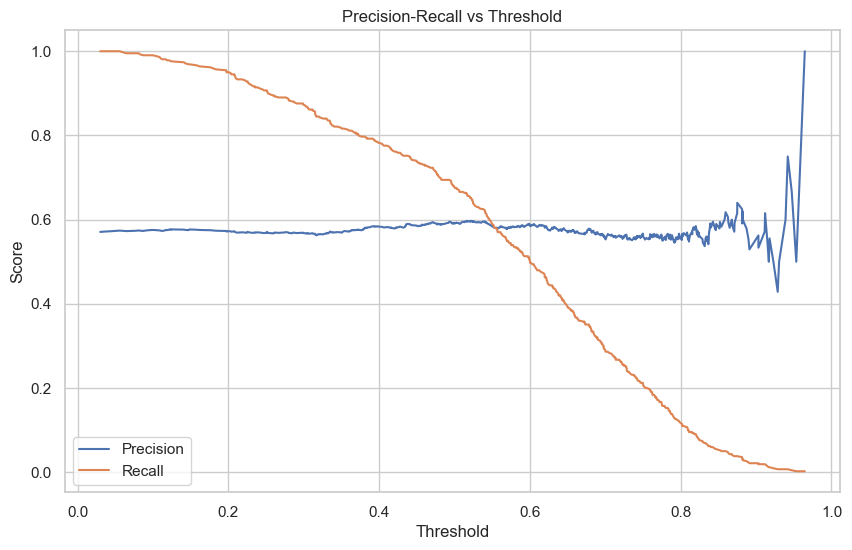

In [44]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall') 
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.42      0.69      0.52       315
           1       0.56      0.29      0.38       419

    accuracy                           0.46       734
   macro avg       0.49      0.49      0.45       734
weighted avg       0.50      0.46      0.44       734



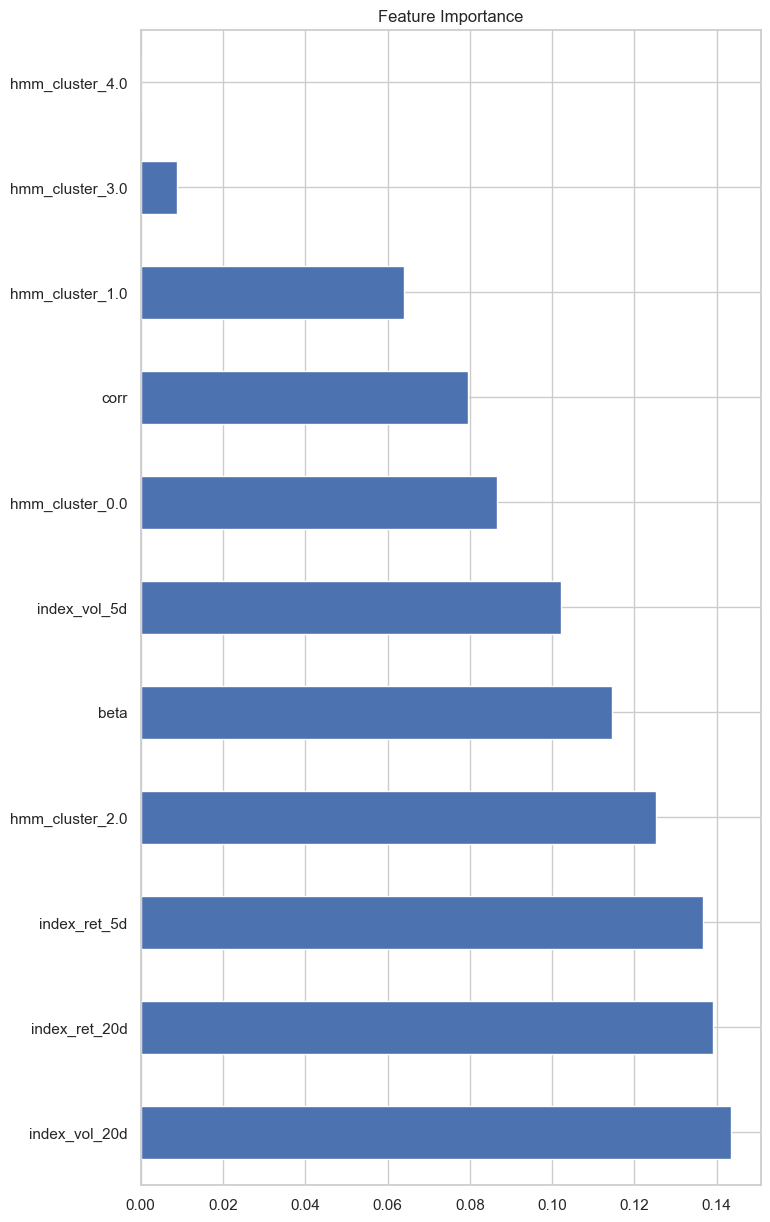

In [72]:
# plot feature importance
plt.figure(figsize=(8,15))
importance = pd.Series(xgb.feature_importances_, index=X_train_scaled.columns)
importance = importance.sort_values(ascending=False)
importance.plot(kind='barh', title='Feature Importance')
plt.show()

In [23]:
y_train.value_counts(), y_test.value_counts()

(result
 1    1909
 0    1026
 Name: count, dtype: int64,
 result
 1    477
 0    257
 Name: count, dtype: int64)

In [24]:
1909/1026, 1026/1909

(1.8606237816764133, 0.5374541644840231)

In [28]:
class_weights[0]/class_weights[1]

1.860623781676413

In [45]:
# optuna hyperparameter tuning for xgboost
def objective(trial):
    param = {
        'scale_pos_weight': class_weights[1]/class_weights[0],
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        # 'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        # 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    
    xgb = XGBClassifier(**param)
    xgb.fit(X_train_scaled, y_train)
    preds = xgb.predict(X_test_scaled)
    f1 = f1_score(y_test, preds)
    
    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300)
print("Best trial:")
trial = study.best_trial
print(f"  F1 Score: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")    

[I 2025-10-08 19:22:29,224] A new study created in memory with name: no-name-9543347a-dffe-4223-b4ef-03671ed535e4
[I 2025-10-08 19:22:30,630] Trial 0 finished with value: 0.3377609108159393 and parameters: {'n_estimators': 300, 'max_depth': 15, 'learning_rate': 0.1366291289599157}. Best is trial 0 with value: 0.3377609108159393.
[I 2025-10-08 19:22:31,199] Trial 1 finished with value: 0.3508771929824561 and parameters: {'n_estimators': 139, 'max_depth': 12, 'learning_rate': 0.13398852444200296}. Best is trial 1 with value: 0.3508771929824561.
[I 2025-10-08 19:22:31,795] Trial 2 finished with value: 0.3462246777163904 and parameters: {'n_estimators': 216, 'max_depth': 8, 'learning_rate': 0.0406292307996063}. Best is trial 1 with value: 0.3508771929824561.
[I 2025-10-08 19:22:32,769] Trial 3 finished with value: 0.3326959847036329 and parameters: {'n_estimators': 190, 'max_depth': 18, 'learning_rate': 0.18918811274928704}. Best is trial 1 with value: 0.3508771929824561.
[I 2025-10-08 19:

Best trial:
  F1 Score: 0.4500846023688663
  Params: 
    n_estimators: 50
    max_depth: 3
    learning_rate: 0.24504786215696017


In [113]:
class_weights[1] / class_weights[0]

0.5374541644840231

In [114]:
class_weights

{1: 1.5374541644840232, 0: 2.8606237816764133}

In [ ]:


def objective(trial):
    scale_pos_weight = class_weights[1] / class_weights[0]

    # Hyperparameters to tune
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        # 'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        # 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }

    xgb = XGBClassifier(**param)
        
    xgb.fit(X_train_scaled, y_train)
    
    y_proba = xgb.predict_proba(X_test_scaled)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores_thr = 2 * (precision * recall) / (precision + recall + 1e-9)
    best_idx = np.argmax(f1_scores_thr)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

    y_pred = (y_proba >= best_threshold).astype(int)

    f1 = f1_score(y_test, y_pred, pos_label=1)
        # f1_scores.append(f1)

    return f1


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300)
print("Best trial:")
trial = study.best_trial
print(f"  F1 Score: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")    


[I 2025-10-06 00:40:30,686] A new study created in memory with name: no-name-bed9a8ae-b9a0-4aaa-b6b5-fc660218deed
[I 2025-10-06 00:40:31,465] Trial 0 finished with value: 0.8093056045118082 and parameters: {'n_estimators': 197, 'max_depth': 11, 'learning_rate': 0.196516364250166}. Best is trial 0 with value: 0.8093056045118082.
[I 2025-10-06 00:40:32,660] Trial 1 finished with value: 0.809004572634541 and parameters: {'n_estimators': 195, 'max_depth': 20, 'learning_rate': 0.27215079878238047}. Best is trial 0 with value: 0.8093056045118082.
[I 2025-10-06 00:40:32,936] Trial 2 finished with value: 0.809004572634541 and parameters: {'n_estimators': 111, 'max_depth': 7, 'learning_rate': 0.15939239229830918}. Best is trial 0 with value: 0.8093056045118082.
[I 2025-10-06 00:40:34,349] Trial 3 finished with value: 0.809004572634541 and parameters: {'n_estimators': 260, 'max_depth': 17, 'learning_rate': 0.1867147621557883}. Best is trial 0 with value: 0.8093056045118082.
[I 2025-10-06 00:40:3

Best trial:
  F1 Score: 0.8119022316684378
  Params: 
    n_estimators: 65
    max_depth: 3
    learning_rate: 0.022931909731849283


In [33]:
def objective_business(trial):
    scale_pos_weight = trial.suggest_float('scale_pos_weight', 0.3, 2.0)
    threshold = trial.suggest_float('threshold', 0.3, 0.8)
    
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }
    
    xgb = XGBClassifier(**param)
    xgb.fit(X_train_scaled, y_train)
    
    y_proba = xgb.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    # Get confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Business logic: 
    # - Each missed profit costs us potential gain
    # - Each missed loss costs us actual money
    # - Each false alarm costs us missed opportunity
    
    profit_captured = tn  # True negatives = correctly identified profits
    profits_missed = fn   # False negatives = missed profits  
    losses_caught = tp    # True positives = caught losses
    losses_missed = fp    # False positives = missed losses (predicted profit but was loss)
    
    # Custom business score
    business_score = (
        profit_captured * 1.0 +      # Each profit captured
        losses_caught * 2.0 -        # Each loss avoided (higher weight)
        profits_missed * 0.5 -       # Each profit missed (opportunity cost)
        losses_missed * 3.0          # Each loss taken (actual cost)
    )
    
    return business_score

def objective_balanced_v2(trial):
    scale_pos_weight = trial.suggest_float('scale_pos_weight', 0.5, 3.0)
    threshold = trial.suggest_float('threshold', 0.4, 0.7)
    
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }
    
    xgb = XGBClassifier(**param)
    xgb.fit(X_train_scaled, y_train)
    
    y_proba = xgb.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    class_0_recall = recall_score(y_test, y_pred, pos_label=0)
    class_1_recall = recall_score(y_test, y_pred, pos_label=1) 
    class_1_precision = precision_score(y_test, y_pred, pos_label=1)
    
    # Rebalanced weights - prioritize loss detection more
    weighted_score = (
        0.25 * class_0_recall +      # Reduced weight for profit capture
        0.50 * class_1_recall +      # Higher priority on catching losses
        0.25 * class_1_precision     # Maintain some precision
    )
    
    return weighted_score

study = optuna.create_study(direction="maximize")
study.optimize(objective_balanced_v2, n_trials=300)
print("Best trial:")
trial = study.best_trial
print(f"  F1 Score: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")    

[I 2025-10-06 15:58:20,743] A new study created in memory with name: no-name-f4fd2a25-ff94-4b25-a0e3-b69a0916acc5
[I 2025-10-06 15:58:21,916] Trial 0 finished with value: 0.5444485335774727 and parameters: {'scale_pos_weight': 0.9038191388089949, 'threshold': 0.6519739358932682, 'n_estimators': 144, 'max_depth': 18, 'learning_rate': 0.011654970628045047}. Best is trial 0 with value: 0.5444485335774727.
[I 2025-10-06 15:58:22,688] Trial 1 finished with value: 0.6696525869235516 and parameters: {'scale_pos_weight': 1.9027072004819252, 'threshold': 0.4700522008845471, 'n_estimators': 128, 'max_depth': 13, 'learning_rate': 0.01668230918803544}. Best is trial 1 with value: 0.6696525869235516.
[I 2025-10-06 15:58:23,777] Trial 2 finished with value: 0.5435498846614448 and parameters: {'scale_pos_weight': 0.657738184430643, 'threshold': 0.6627732480555576, 'n_estimators': 232, 'max_depth': 11, 'learning_rate': 0.0492006280825666}. Best is trial 1 with value: 0.6696525869235516.
[I 2025-10-06 

Best trial:
  F1 Score: 0.6809327636891893
  Params: 
    scale_pos_weight: 2.56995875232523
    threshold: 0.5632695939400867
    n_estimators: 151
    max_depth: 4
    learning_rate: 0.10795029249990817
